# 1) Chargement des données

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import os

# ACP
from sklearn.decomposition import PCA
from sklearn import preprocessing

# K-means
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Regression
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import RocCurveDisplay # Updated import
from sklearn.feature_selection import RFECV

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad, het_white

DATA_PATH = "/content/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df_billets = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")

❌ Erreur lors du chargement : name 'df' is not defined
⚠️ Tu as bien lu le code avant de l'executer ? 😏


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

In [ ]:
#Analyse types de données
df_billets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB



6 variables quantitatives et 1 variable qualitative (is_genuine)

In [ ]:
#pas de données en doublon
df_billets.duplicated().sum()

np.int64(0)

In [ ]:
#Données manquantes
df_billets.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


In [ ]:
print("La variable margin_low compte",df_billets.margin_low.isnull().sum(),"lignes avec des valeurs nulles !")


La variable margin_low compte 37 lignes avec des valeurs nulles !


In [ ]:
df_billets.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [ ]:
#Comptage des billets vrais vs faux
df_billets['is_genuine'].value_counts()

,count
is_genuine,
True,1000
False,500


In [ ]:
df= df_billets.dropna(inplace=False)

In [ ]:
# Ajoutez une constante pour la régression
X = sm.add_constant(df[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']])

# Créez le modèle de régression
model = sm.OLS(df['margin_low'], X).fit()

# Affichez les résultats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     266.1
Date:                Sun, 31 May 2026   Prob (F-statistic):          2.60e-202
Time:                        07:51:06   Log-Likelihood:                -1001.3
No. Observations:                1463   AIC:                             2015.
Df Residuals:                    1457   BIC:                             2046.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.9948      9.656      2.382   

In [ ]:
#Verification valeurs manquantes
df.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0


In [ ]:
df.corr(numeric_only=True)["margin_low"].sort_values(ascending=False)

,margin_low
margin_low,1.000000
margin_up,0.431606
height_right,0.391085
height_left,0.302643
diagonal,-0.111534
length,-0.666753
is_genuine,-0.783032


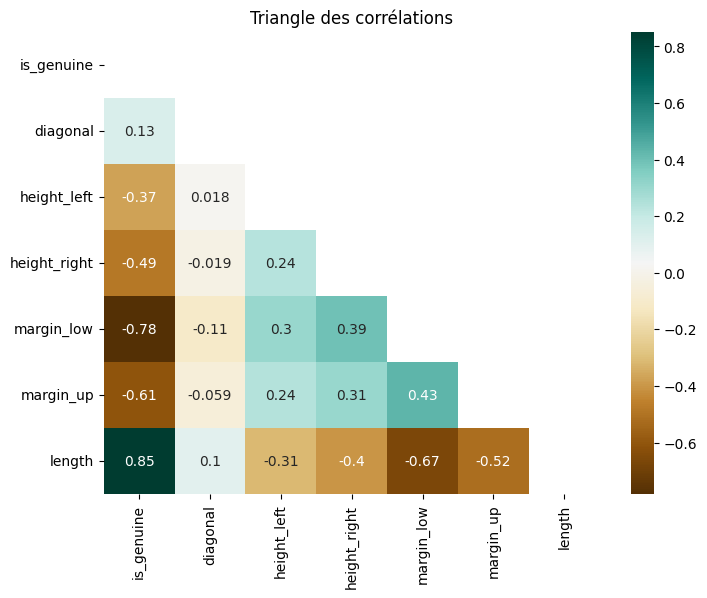

In [ ]:
matrix = df.corr()
mask = np.triu(np.ones_like(matrix))
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, mask=mask, annot=True, cmap='BrBG')
plt.title('Triangle des corrélations')
plt.show()

Les 2 variables quantitatives les plus corrélés sont 'length' et 'margin_low', l'une est corrélé positivement et l'autre négativement !

* 'length' est aussi assez bien corréler à 'diagonal' et 'height_left'
* 'margin_up' est assez bien corréler à 'margin_low'

Liste des variables les plus corréler à 'is_genuine' dans l'odre décroissant :

* 'length'
* 'diagonal'
* 'height_left
* 'height_right'
* 'margin_up'
* 'margin_low'

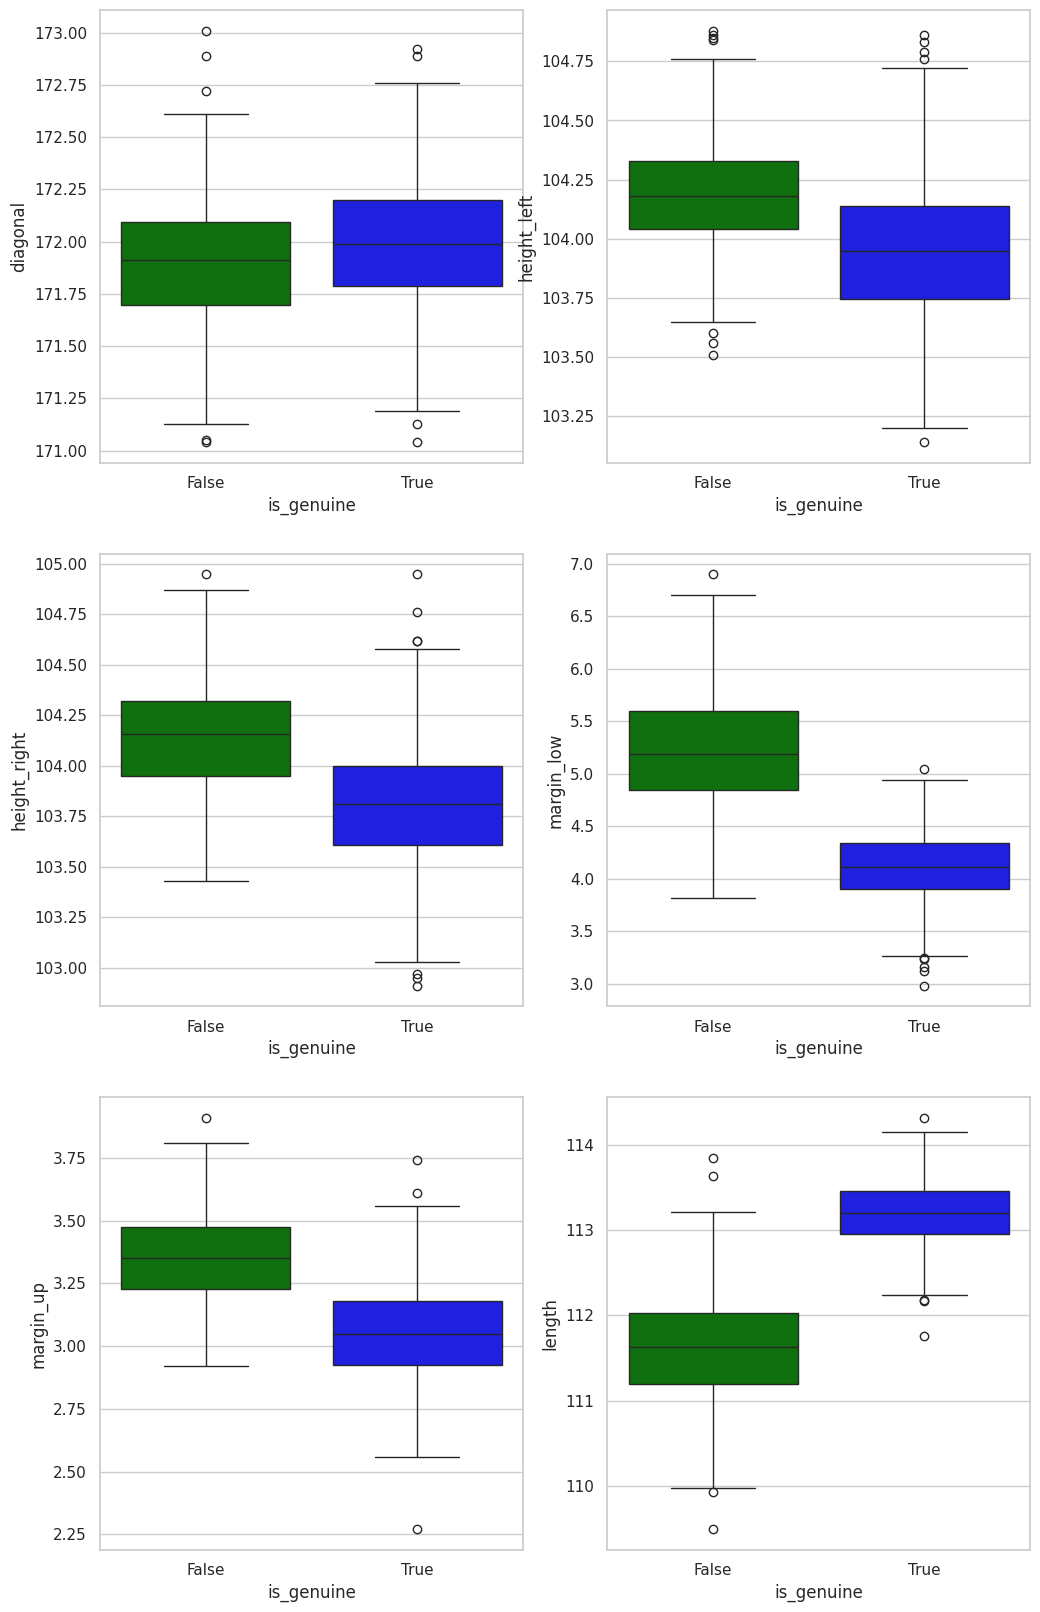

In [ ]:
plt.figure(figsize=(12, 20))
sns.set(style="whitegrid")

palette_colors = {True: 'blue', False: 'green'}

plt.subplot(321)
sns.boxplot(data=df, x='is_genuine', y='diagonal', hue='is_genuine', palette=palette_colors, legend=False)

plt.subplot(322)
sns.boxplot(data=df, x='is_genuine', y='height_left', hue='is_genuine', palette=palette_colors, legend=False)

plt.subplot(323)
sns.boxplot(data=df, x='is_genuine', y='height_right', hue='is_genuine', palette=palette_colors, legend=False)

plt.subplot(324)
sns.boxplot(data=df, x='is_genuine', y='margin_low', hue='is_genuine', palette=palette_colors, legend=False)

plt.subplot(325)
sns.boxplot(data=df, x='is_genuine', y='margin_up', hue='is_genuine', palette=palette_colors, legend=False)

plt.subplot(326)
sns.boxplot(data=df, x='is_genuine', y='length', hue='is_genuine', palette=palette_colors, legend=False)

plt.show(block=False)

**Nous confirmons que es variables 'length' et 'margin_low' ont le plus de différence entre les vrais et les faux billets** !

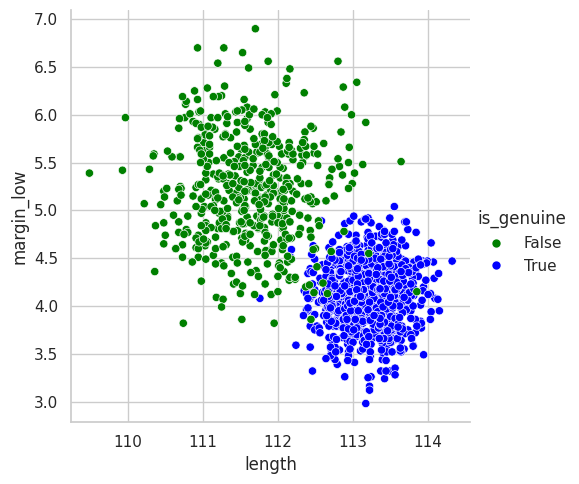

In [ ]:
# Visualisation des vrais/faux billets sur 'margin_low' par rapport à 'length'

x = df['length']
y = df['margin_low']
z = df['is_genuine']

sns.relplot(x = x, y = y, hue= z, palette=palette_colors)
plt.show()

In [ ]:
# Suppréssion des lignes contenant 1 valeurs manquantes
df_billets = df.dropna(inplace=False)

# Variable de prédiction
X = df_full[['length']]
# Variable a prédir
y = df_full[['margin_low']]

lr = LinearRegression()
lr.fit(X, y)

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# lignes avec valeur connue (from df_billets)
train_df = df_billets[df_billets["margin_low"].notna()]

# lignes à compléter (from df_billets)
predict_df = df_billets[df_billets["margin_low"].isna()]

# variables explicatives
features = ["height_left", "height_right", "margin_up", "length"]

X_train = train_df[features]
y_train = train_df["margin_low"]

# modèle
model = LinearRegression()
model.fit(X_train, y_train)

# prédiction des valeurs manquantes
X_predict = predict_df[features]
predicted_values = model.predict(X_predict)

# remplacement dans df_billets
df_billets.loc[df_billets["margin_low"].isna(), "margin_low"] = predicted_values

# Update df to be the imputed df_billets for consistency with subsequent cells
df = df_billets.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [ ]:
df.columns

Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length'],
      dtype='object')

In [ ]:
X = df[['diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length']] # Toutes les colonnes sauf la cible
y = df["is_genuine"] # La colonne cible

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Use scaler on X_train and X_test.

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.

# 2) Entrainez le modèle avec vos données X_train et y_train

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.


In [ ]:
#on entraîne ce modèle sur les données avec la méthode fit
from sklearn.linear_model import LogisticRegression

# Initialisez votre modèle ici, par exemple une Régression Logistique
reg = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)

In [ ]:
y_pred_lr = reg.predict(X_test)
y_pred_proba = reg.predict_proba(X_test)

In [ ]:
# et on obtient directement un score.
print('Coef :', reg.coef_)
print('R² :',reg.score(X,y))

Coef : [[-0.27242507 -1.4915954  -1.95087771 -3.33632349 -2.99853389  3.8238269 ]]
R² : 0.9893333333333333


In [ ]:
# Erreur de la moyenne absolue
print('MAE :', metrics.mean_absolute_error(y_test, y_pred_lr))
# Erreur de la moyenne absolue au carré
print('MSE :', metrics.mean_squared_error(y_test, y_pred_lr))
# Erreur quadratique moyenne est la racine carrée de la moyenne de la somme des carrés des valeurs résiduelles.
print('RMSE :', np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)))

MAE : 0.01
MSE : 0.01
RMSE : 0.1



Les coefficients représentent l'importance des différentes variables dans la prédiction de y. Plus le coef est grand plus la variable est significative pour prédire y !

Le R² est le coefficient de détermination, qui nous permet de savoir si notre modele est bon ou pas. Plus le coefficient de détermination est proche de 1, meilleur est notre modèle !

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
# predictions
y_pred_lr = reg.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("ROC-AUC", round(roc_auc_score(y_test, reg.predict_proba(X_test)[:, 1]), 4))

Accuracy: 0.99
Precision: 0.9845
Recall: 1.0
ROC-AUC 0.9997


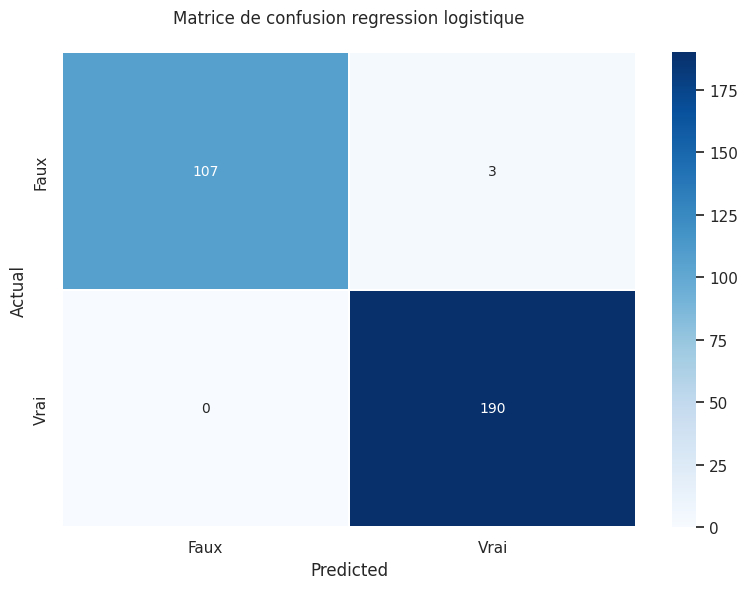

In [ ]:
matrice = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(matrice, annot=True, fmt=".3g", cmap='Blues', linecolor="white", linewidths=0.3, xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'])

plt.title("Matrice de confusion regression logistique\n")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       1.00      0.97      0.99       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



--- KNeighborsClassifier --- 
MAE (KNN): 0.01
MSE (KNN): 0.01
RMSE (KNN): 0.1
Accuracy (KNN): 0.99
Precision (KNN): 0.9845
Recall (KNN): 1.0
ROC-AUC (KNN): 0.9954


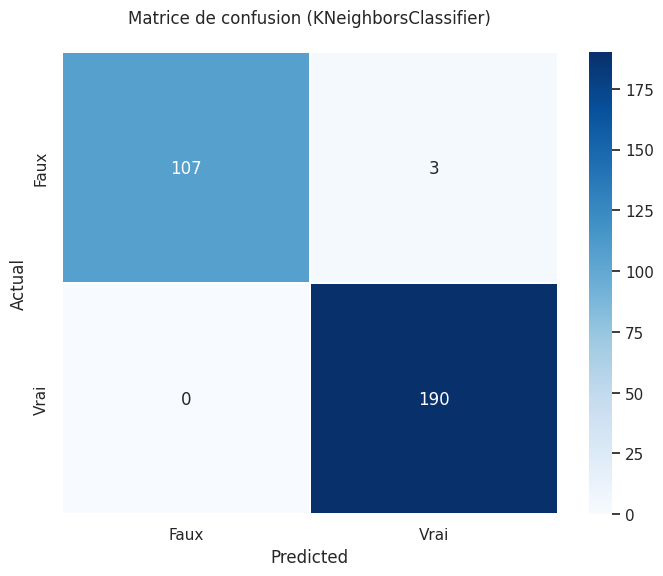

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# Répéter les même étapes que pour la régression logistique mais avec le KNN.

# 1) Initialisez un KNeighborsClassifier
knn = KNeighborsClassifier()

# 2) Entraînez le modèle avec vos données X_train et y_train
knn.fit(X_train, y_train)

# 3) Utiliser le KNeighborsClassifier pour déterminer les vrais / faux billets de X_test.
y_pred_knn = knn.predict(X_test)

# Évaluation du modèle KNN
print("--- KNeighborsClassifier --- ")
print('MAE (KNN):', metrics.mean_absolute_error(y_test, y_pred_knn))
print('MSE (KNN):', metrics.mean_squared_error(y_test, y_pred_knn))
print('RMSE (KNN):', np.sqrt(metrics.mean_squared_error(y_test, y_pred_knn)))

print("Accuracy (KNN):", round(accuracy_score(y_test, y_pred_knn), 4))
print("Precision (KNN):", round(precision_score(y_test, y_pred_knn), 4))
print("Recall (KNN):", round(recall_score(y_test, y_pred_knn), 4))
# For ROC-AUC, we need probabilities, not just predictions
# Check if the model has predict_proba, if not, skip ROC-AUC or handle differently
if hasattr(knn, 'predict_proba'):
    print("ROC-AUC (KNN):", round(roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]), 4))
else:
    print("ROC-AUC (KNN): predict_proba not available for this model.")

# Matrice de confusion pour KNN
matrice_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8,6))
sns.heatmap(matrice_knn, annot=True, fmt=".3g", cmap='Blues', linecolor="white", linewidths=0.3, xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'])
plt.title("Matrice de confusion (KNeighborsClassifier)\n")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       1.00      0.97      0.99       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



--- RandomForestClassifier --- 
Accuracy (RFC): 0.99
Precision (RFC): 0.9845
Recall (RFC): 1.0
Gradient Boosting Accuracy: 0.99
Gradient Boosting Precision: 0.9844559585492227
Gradient Boosting Recall: 1.0
ROC-AUC (RFC): 0.9999


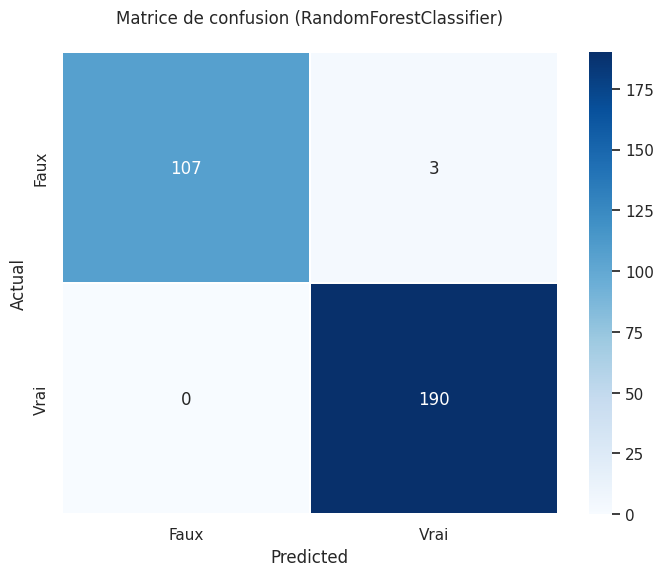

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# 1) Initialisez un RandomForestClassifier
# Vous pouvez ajuster les paramètres ici, par exemple n_estimators pour le nombre d'arbres.
rfc = RandomForestClassifier(random_state=42)

# 2) Entraînez le modèle avec vos données X_train et y_train
rfc.fit(X_train, y_train)

# 3) Utiliser le RandomForestClassifier pour déterminer les vrais / faux billets de X_test.
y_pred_rfc = rfc.predict(X_test)

# Entraîner un modèle de boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

# Évaluation du modèle RandomForestClassifier
print("--- RandomForestClassifier --- ")

print("Accuracy (RFC):", round(accuracy_score(y_test, y_pred_rfc), 4))
print("Precision (RFC):", round(precision_score(y_test, y_pred_rfc), 4))
print("Recall (RFC):", round(recall_score(y_test, y_pred_rfc), 4))

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Precision:", precision_score(y_test, y_pred_gb))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))

# Pour ROC-AUC, nous avons besoin des probabilités
if hasattr(rfc, 'predict_proba'):
    print("ROC-AUC (RFC):", round(roc_auc_score(y_test, rfc.predict_proba(X_test)[:, 1]), 4))
else:
    print("ROC-AUC (RFC): predict_proba not available for this model.")

# Matrice de confusion pour RandomForestClassifier
matrice_rfc = confusion_matrix(y_test, y_pred_rfc)
plt.figure(figsize=(8,6))
sns.heatmap(matrice_rfc, annot=True, fmt=".3g", cmap='Blues', linecolor="white", linewidths=0.3, xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'])
plt.title("Matrice de confusion (RandomForestClassifier)\n")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

       False       1.00      0.97      0.99       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
np.random.seed(808)
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?

In [ ]:
df_kmeans = df.drop(columns="is_genuine", inplace=False)
X = df_kmeans.values
y = df["is_genuine"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

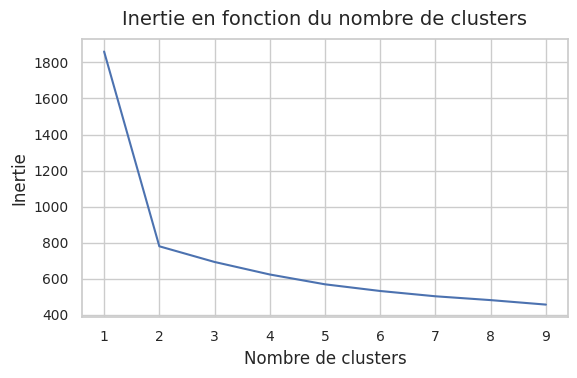

In [ ]:
# Une liste vide pour enregistrer les inerties :
inertia_list = []

# Pour chaque nombre de clusters :
for k in range(1, 10) :
    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k, n_init=10, init='random', random_state=10).fit(X_train)
    # On enregistre l'inertie obtenue
    inertia_list.append(kmeans.inertia_)

plt.rcParams.update({'figure.autolayout': True, 'font.size': 14})

fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.set_ylabel("Inertie", fontsize=12)
ax.set_xlabel("Nombre de clusters", fontsize=12)
ax.tick_params(axis='x', which='major', labelsize=10)
ax.tick_params(axis='y', which='major', labelsize=10)

ax = plt.plot(range(1, 10), inertia_list)

plt.title("Inertie en fonction du nombre de clusters", pad=10, fontsize=14)

plt.show()


n_clusters 2
score -6192.6355515687255
silhouette_score:  0.49688444268640053

n_clusters 3
score -2269.972831898881
silhouette_score:  0.6045530064771639

n_clusters 4
score -1999.640020657523
silhouette_score:  0.4806377095129729

n_clusters 5
score -1779.015222825795
silhouette_score:  0.405270613153201

n_clusters 6
score -1511.0630570386363
silhouette_score:  0.3201297614193394

n_clusters 7
score -1311.727988101382
silhouette_score:  0.32135276281263725

n_clusters 8
score -1168.9245886975186
silhouette_score:  0.32463863541079563


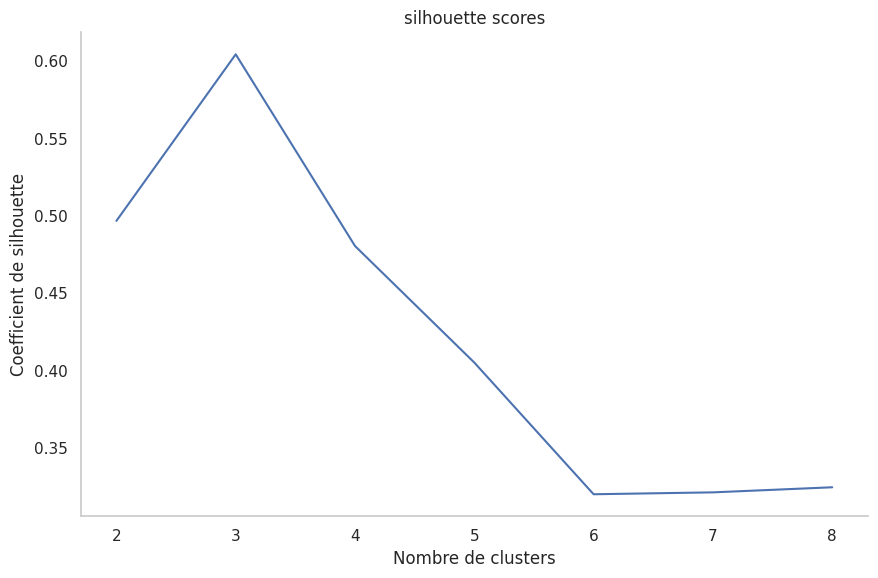

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Define centers for make_blobs (from kernel state)
centers = [[2, 2], [-2, -2], [2, -2]]

X, labels_true = make_blobs(n_samples=1500, centers=centers, cluster_std=0.9)

silhouette_scores = []
# Changed range to start from 2, as silhouette_score requires at least 2 clusters.
for n_clusters in range(2,9):
    print()
    print("n_clusters",n_clusters)
    k_means = KMeans(init="k-means++", n_clusters=n_clusters, random_state = 808 , n_init = 'auto'  )
    k_means.fit(X)
    print("score", k_means.score(X))

    k_means_labels = k_means.predict(X)
    print("silhouette_score: ", silhouette_score(X,k_means_labels ))
    silhouette_scores.append(silhouette_score(X,k_means_labels ))

fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(1, 1, 1)
# Changed range for plotting to match the calculation range.
plt.plot(range(2,9), silhouette_scores)
ax.set_title('silhouette scores')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Nombre de clusters')
ax.set_ylabel('Coefficient de silhouette')
plt.grid()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2)
kmeans.fit_transform(X_train)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ensure scaler is fitted on X_train first
# If `scaler` was already defined as StandardScaler() but not fitted on X_train,
# we fit it here. This is the correct way to train the scaler.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Now, scale the centroids using the scaler that was fitted on X_train
centroids_scaled = scaler.transform(centroids)

# Initialize and fit PCA on the scaled X_train
pca = PCA(n_components=2) # Assuming 2 components for 'F1', 'F2'
pca.fit(X_train_scaled)

# Project the scaled centroids using the fitted PCA
centroids_proj = pca.transform(centroids_scaled)

# Création d'un dataframe pour plus de clarté:
centroids_proj = pd.DataFrame(centroids_proj,
                              columns = ["F1", "F2"],
                              index=["cluster_0", "cluster_1"])

print(centroids_proj)

                 F1        F2
cluster_0  0.964741  0.045116
cluster_1 -2.114220 -0.098872


In [ ]:
# Instanciation
scaler = StandardScaler()
# Transformation – centrage-réduction
X_scaled = scaler.fit_transform(X_train)

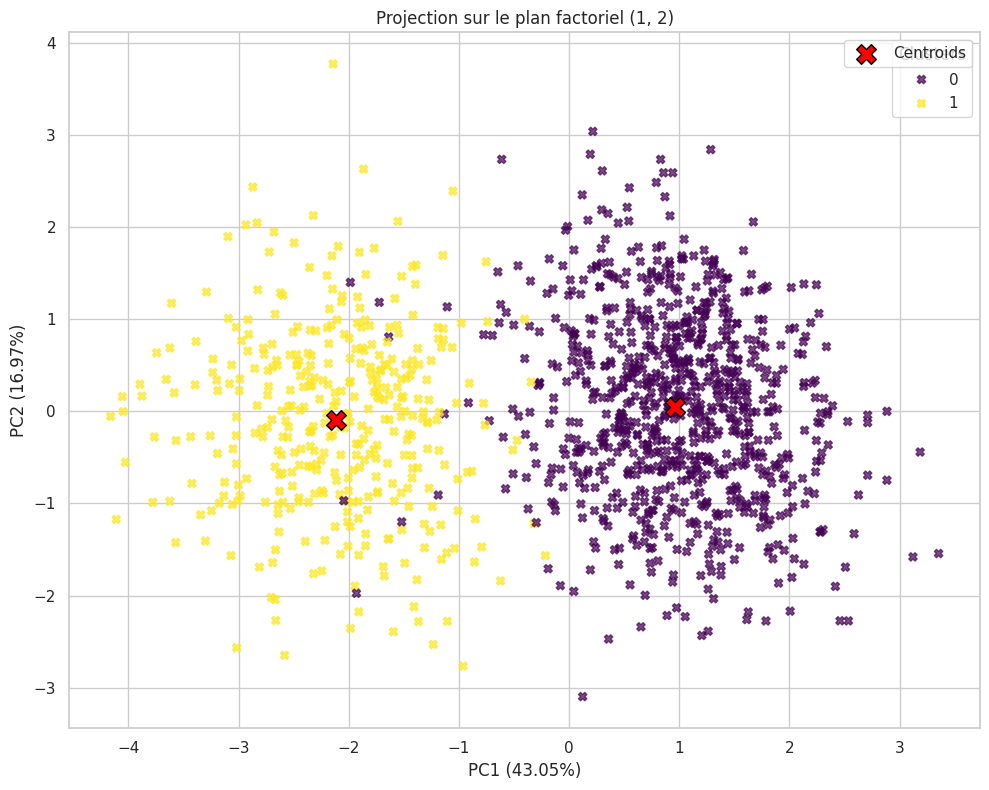

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported if not already globally available

# Define the display_factorial_planes function
def display_factorial_planes(X_proj, x_y, pca, figsize=(10, 8), marker='o', alpha=0.7, clusters=None, centroids=None):
    """
    Displays the factorial planes of a PCA, optionally with clusters and centroids.

    Args:
        X_proj (np.ndarray): Projected data points on the principal components.
        x_y (tuple): A tuple (x_axis_component, y_axis_component) specifying which principal
                     components to plot (e.g., (0, 1) for PC1 vs PC2).
        pca (sklearn.decomposition.PCA): The fitted PCA model.
        figsize (tuple): Figure size for the plot.
        marker (str): Marker style for data points.
        alpha (float): Transparency of data points.
        clusters (np.ndarray, optional): Cluster labels for color-coding points. Defaults to None.
        centroids (pd.DataFrame, optional): DataFrame of projected centroids. Defaults to None.
    """
    # Get explained variance ratios
    components = pca.explained_variance_ratio_

    # Select components for plotting
    x_component, y_component = x_y[0], x_y[1]

    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)

    # Plot data points
    if clusters is not None:
        # Assuming clusters are integer labels, use a colormap
        scatter = ax.scatter(X_proj[:, x_component], X_proj[:, y_component], c=clusters, cmap='viridis', marker=marker, alpha=alpha)
        legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
        ax.add_artist(legend1)
    else:
        ax.scatter(X_proj[:, x_component], X_proj[:, y_component], marker=marker, alpha=alpha)

    # Plot centroids if provided
    if centroids is not None:
        ax.scatter(centroids.iloc[:, x_component], centroids.iloc[:, y_component], marker='X', s=200, color='red', edgecolor='black', label='Centroids')
        ax.legend()

    # Set labels and title
    ax.set_xlabel(f'PC{x_component+1} ({components[x_component]*100:.2f}%)')
    ax.set_ylabel(f'PC{y_component+1} ({components[y_component]*100:.2f}%)')
    ax.set_title(f'Projection sur le plan factoriel ({x_component+1}, {y_component+1})')
    ax.grid(True)
    plt.show()


plt.rcParams.update({'figure.autolayout': True, 'font.size': 10})

X_proj = pca.transform(X_scaled)
x_y = (0,1)

# Call the defined function directly
display_factorial_planes(X_proj, x_y, pca, figsize=(10,8), marker="X", alpha=0.7, clusters=labels, centroids=centroids_proj)

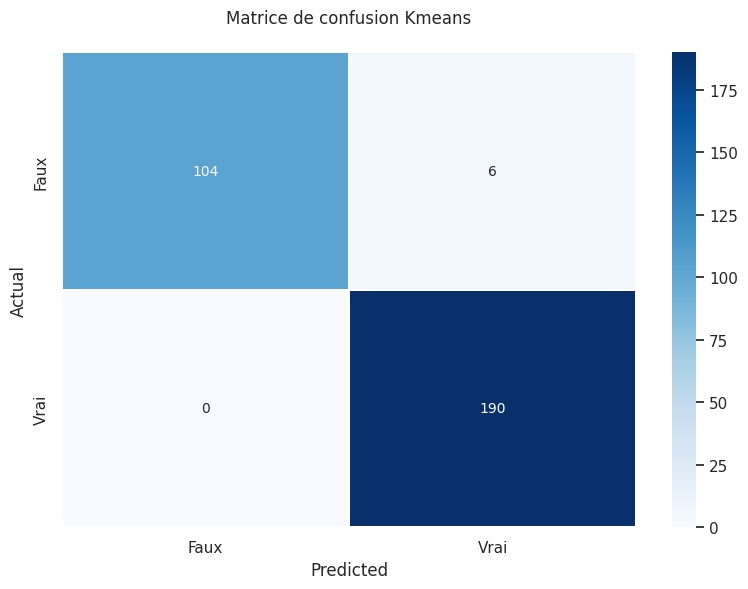

In [ ]:
from sklearn.metrics import confusion_matrix

kmeans = KMeans(n_clusters=2)
kmeans.fit_transform(X_train,y_train)
y_pred = labels
# Remplacer 1 par False et 0 par True
y_pred = y_pred == 0
y_pred_kmeans = kmeans.predict(X_test)

matrice = confusion_matrix(y_test, y_pred_kmeans)

plt.figure(figsize=(8,6))
sns.heatmap(matrice, annot=True, fmt=".3g", cmap='Blues', linecolor="white", linewidths=0.3, xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'])

plt.title("Matrice de confusion Kmeans\n")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_kmeans))

              precision    recall  f1-score   support

       False       1.00      0.95      0.97       110
        True       0.97      1.00      0.98       190

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.98       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
print("score", kmeans.score(X_test))

score -192.63690282271062


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get predictions for X_test using the already fitted kmeans model
y_pred_kmeans_on_test = kmeans.predict(X_test)
# Apply the same transformation used for y_pred_kmeans on training data (assuming 0 is False/fake)
y_pred_kmeans_on_test = y_pred_kmeans_on_test == 0

print("Accuracy:", round(accuracy_score(y_test, y_pred_kmeans), 3))
print("Precision:", round(precision_score(y_test, y_pred_kmeans), 3))
print("Recall:", round(recall_score(y_test, y_pred_kmeans), 3))

Accuracy: 0.98
Precision: 0.969
Recall: 1.0


# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

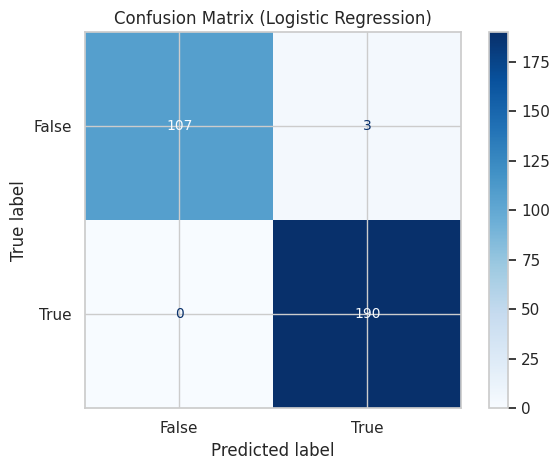

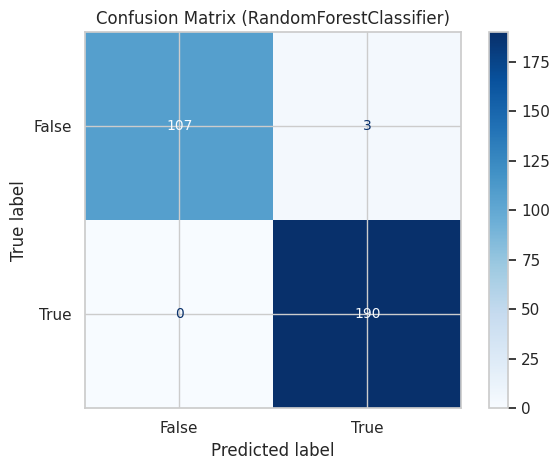

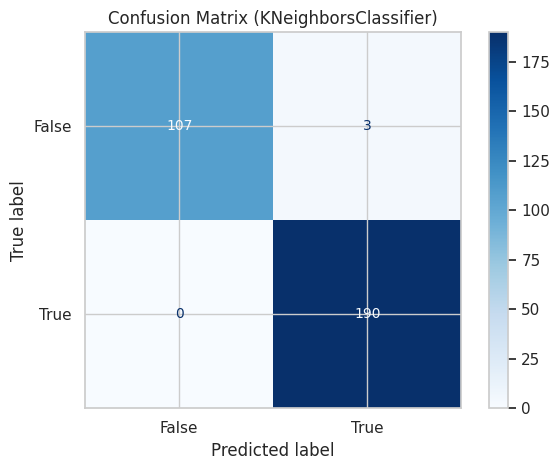

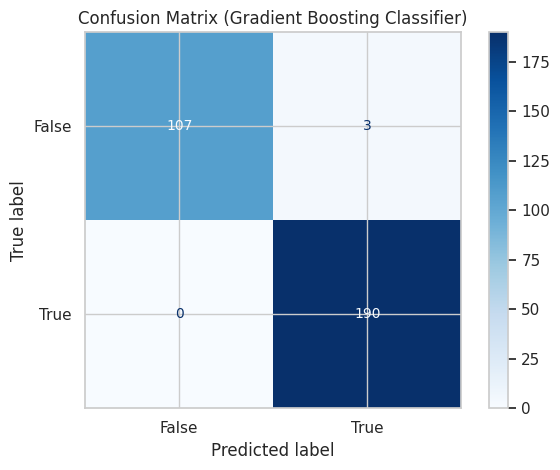

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# C'est là qu'on voit qui sont les bons 😉!

# Prédictions déjà effectuées
y_pred_dict = {
    'Logistic Regression': y_pred_lr,
    'RandomForestClassifier': y_pred_rfc,
    'KNeighborsClassifier': y_pred_knn,
    'Gradient Boosting Classifier': y_pred_gb
}

# Loop through each model and display its confusion matrix
for model_name, predictions in y_pred_dict.items():
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
    disp.plot(cmap='Blues', values_format='.3g')
    plt.title(f'Confusion Matrix ({model_name})')
    plt.show()

Choix du modele !!!
tout les modèles apportent les même resulats, mais je choisirais plutôt la regression logistique car peu de donnée et surtout un modèle plus simple pour modéliser et prédire une cible de catégorie

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [ ]:
from sklearn.pipeline import make_pipeline
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Visualisation des données du fichier

pd.read_csv('/content/billets_production (1).csv')

,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


In [ ]:
# On enregistre les données d'entrainement dans un dictionnaire

data_train = {}
data_train[1] = pca
data_train[2] = reg
data_train

{1: PCA(n_components=2), 2: LogisticRegression(max_iter=1000, random_state=42)}

In [ ]:
import pickle

file = open('train', 'wb')
pickle.dump(data_train, file)
file.close()

In [ ]:
from sklearn.pipeline import make_pipeline
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Ensure X_train, y_train, and reg (fitted LogisticRegression model) are available from previous cells

# Initialize StandardScaler
scaler = StandardScaler()

# Use make_pipeline to include all necessary steps
# (StandardScaler and the fitted LogisticRegression model)
model_pipeline = make_pipeline(scaler, reg)

# Fit the pipeline with the training data
# This step trains the StandardScaler and the LogisticRegression model together
model_pipeline.fit(X_train, y_train)

# Save the fitted pipeline to a file
joblib.dump(model_pipeline, 'logistic_regression_pipeline.joblib')

print("Logistic Regression model pipeline saved as 'logistic_regression_pipeline.joblib'")

Logistic Regression model pipeline saved as 'logistic_regression_pipeline.joblib'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.decomposition import PCA
import pickle
import csv
import joblib
from sklearn.linear_model import LinearRegression # Added for imputation

# Programe de detection de faux billets

def detection_billets(fichier_csv):

    # Import the saved pipeline which includes StandardScaler and LogisticRegression
    pipeline = joblib.load('logistic_regression_pipeline.joblib')

    # Import des données du fichier. Removed 'sep=;' to allow pandas to infer the separator.
    data = pd.read_csv(fichier_csv)

    # --- Fix: Strip whitespace from column names ---
    data.columns = data.columns.str.strip()
    print("Columns after stripping whitespace:", data.columns.tolist())
    print("Head of DataFrame after stripping whitespace:\n", data.head())
    # Separate data with and without missing margin_low for imputation
    train_impute_df = data[data["margin_low"].notna()]
    predict_impute_df = data[data["margin_low"].isna()]

    if not predict_impute_df.empty: # Only impute if there are missing values
        # Features for imputation model (consistent with previous notebook cells)
        imputation_features = ["height_left", "height_right", "margin_up", "length"]

        X_impute_train = train_impute_df[imputation_features]
        y_impute_train = train_impute_df["margin_low"]

        # Train a LinearRegression model for imputation
        imputation_model = LinearRegression()
        imputation_model.fit(X_impute_train, y_impute_train)

        # Predict missing values
        X_impute_predict = predict_impute_df[imputation_features]
        predicted_margin_low = imputation_model.predict(X_impute_predict)

        # Replace NaN values in the original 'data' DataFrame
        data.loc[data["margin_low"].isna(), "margin_low"] = predicted_margin_low

    # Fallback to ensure no NaNs remain in margin_low after imputation
    # This handles cases where LinearRegression prediction might result in NaN for some reason
    if data['margin_low'].isnull().any():
        data['margin_low'].fillna(data['margin_low'].mean(), inplace=True)
    # -------------------------------------------------------------------------

    # Define features based on how the model was trained (X_train columns)
    features_for_prediction = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

    # Prepare X_csv by selecting only the features needed for prediction
    # The pipeline will handle the scaling internally.
    X_csv = data[features_for_prediction]

    # Regression logistique: the pipeline will handle standardisation and prediction
    y_log = pipeline.predict(X_csv)
    pred = pd.DataFrame(y_log)
    pred = pred.rename(columns={0: 'Prédiction'})
    pred = pred.replace({False: 'Faux billet', True: 'Vrais billet'})

    y_proba = pipeline.predict_proba(X_csv)
    proba = pd.DataFrame(y_proba)
    proba = proba.rename(columns={0: 'Probabilité de faux', 1: 'Probabilité de vrais'})

    # Concaténation des données
    prediction = pd.concat([pred, proba], axis = 1)
    res = pd.concat([prediction, data], axis = 1)

    # Recherche des billets à revérifier, car probabilité de Vrais ou Faux infèrieur à 90% !}
    verif_billet = res.loc[(res['Probabilité de vrais'] > 0.10) & (res['Probabilité de vrais'] < 0.90)]

    # Création d'un fichier CSV avec les résultats
    res.to_csv('Resultats_Detections_Billets.csv', index = False) # index=False to avoid writing pandas index

    # Création d'un fichier CSV avec les billets à revérifier si il y en a !
    if(len(verif_billet)>0):
        verif_billet.to_csv('Billets_à_Vérifier.csv', index = False) # index=False to avoid writing pandas index

    return(res)

In [ ]:
detection_billets('/content/billets_production (1).csv')

Columns after stripping whitespace: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'id']
Head of DataFrame after stripping whitespace:
    diagonal  height_left  height_right  margin_low  margin_up  length   id
0    171.76       104.01        103.54        5.21       3.30  111.42  A_1
1    171.87       104.17        104.13        6.00       3.31  112.09  A_2
2    172.00       104.58        104.29        4.99       3.39  111.57  A_3
3    172.49       104.55        104.34        4.44       3.03  113.20  A_4
4    171.65       103.63        103.56        3.77       3.16  113.33  A_5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,Prédiction,Probabilité de faux,Probabilité de vrais,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,Faux billet,0.997884,0.002116,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,Faux billet,0.999690,0.000310,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,Faux billet,0.999561,0.000439,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,Vrais billet,0.030169,0.969831,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,Vrais billet,0.000183,0.999817,171.65,103.63,103.56,3.77,3.16,113.33,A_5
